<a href="https://colab.research.google.com/github/zainabali12212/Smart-Medicine-OCR-Project/blob/main/Stage3-Geometric-Analysis/Stage%203%3A%20Geometric%20Correction%20and%20Orientation%20Alignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 3: Advanced Geometric Pre-processing & OCR

**This notebook evaluates the system's robustness against severe perspective tilts. It demonstrates the evolution from basic bounding-box rotation to advanced Line-Detection (Hough Transform), ensuring accurate bilingual extraction even under challenging camera angles (up to 45°).**

## 🛠 Environment Setup
This section installs the Tesseract OCR engine with Arabic & English language packs and imports the advanced image processing libraries (OpenCV, NumPy) required for geometric rectification and bilingual extraction.

In [1]:
# 1. Install Tesseract OCR + Arabic Language Pack
!apt-get install -y tesseract-ocr tesseract-ocr-ara
!pip install pytesseract

# 2. Import necessary libraries
import numpy as np
import cv2
import pytesseract
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

print("Environment Ready: Arabic OCR engine and libraries installed.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-ara is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Environment Ready: Arabic OCR engine and libraries installed.


---

## 🧪 Tested Scenarios (Cases)

### **Case 1: Severe Image Skew (Legacy Bounding Box Method)**
* **Challenge:** The image is taken at a sharp 45-degree angle. This test evaluates if the standard bounding box logic can detect and rectify severe tilts.
* **Observation:** We will observe how the `minAreaRect` approach fails to distinguish between the package boundaries and the actual text orientation, leading to a failed OCR attempt.

#### **Step 1: Image Upload & Visualization**
Uploading the medicine label and displaying the original state to visualize the degree of skew before any processing.

Upload image for CASE 1:


Saving photo_2026-02-25_10-06-30.jpg to photo_2026-02-25_10-06-30 (1).jpg


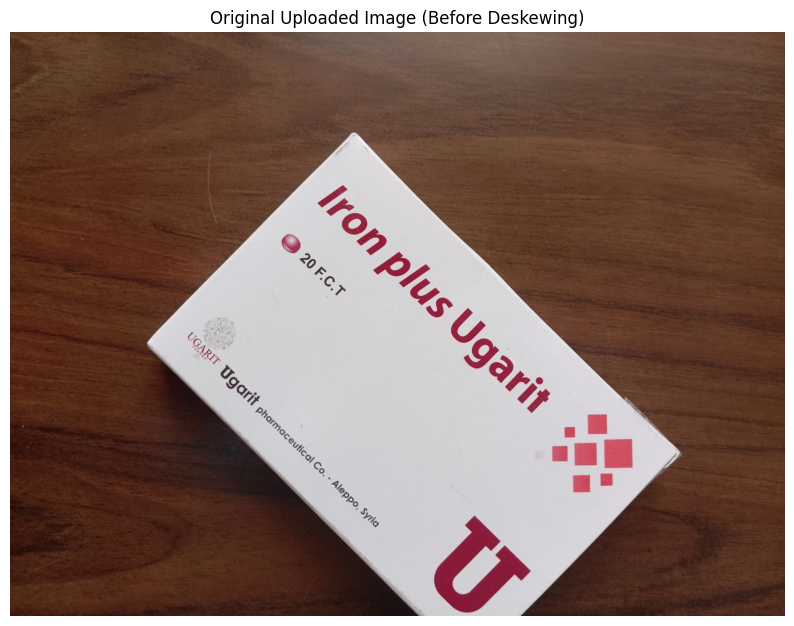

In [2]:
print("Upload image for CASE 1:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
image = cv2.imread(file_name)

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Uploaded Image (Before Deskewing)")
plt.axis('off')
plt.show()

#### **Step 2: Adaptive Scaling & Initial Deskewing**
Resizing the image and attempting to correct the tilt using the **Minimum Area Rectangle** method.

Detected Angle: -0.00 degrees. Correction applied.


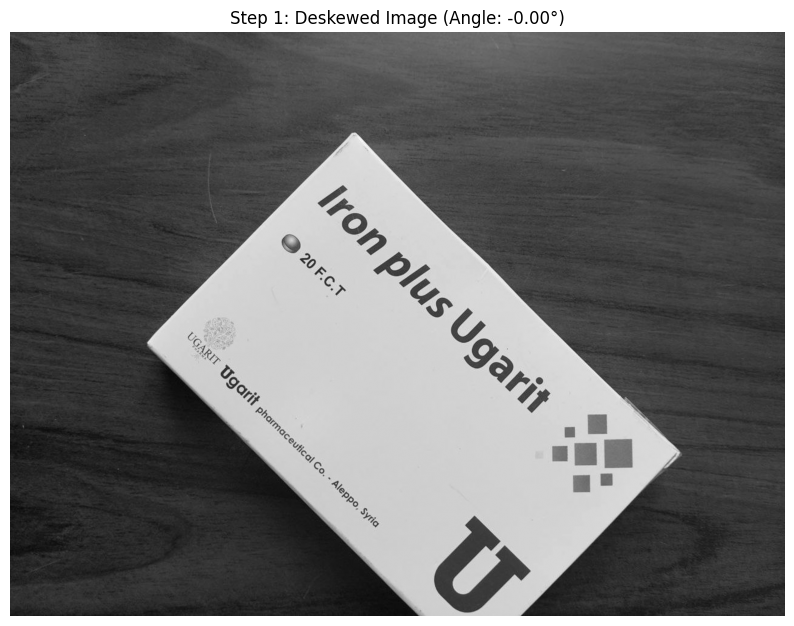

In [3]:
# Step 1: Adaptive Resizing, Grayscale & Deskewing
# 1. Resize
img_resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# 2. Convert to Grayscale
gray_image = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

# 3. Deskewing Logic (Correcting Tilt)
# Threshold the image to focus on text blocks
thresh = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

# Find all white pixels (text) and get their coordinates
coords = np.column_stack(np.where(thresh > 0))

# Find the minimum bounding box that encloses the text and get the angle
angle = cv2.minAreaRect(coords)[-1]

# Adjust the angle logic
if angle < -45:
    angle = -(90 + angle)
else:
    angle = -angle

# Rotate the image to deskew
(h, w) = gray_image.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, angle, 1.0)
rotated_gray = cv2.warpAffine(gray_image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

print(f"Detected Angle: {angle:.2f} degrees. Correction applied.")

# Display the result
plt.figure(figsize=(10,10))
plt.imshow(rotated_gray, cmap='gray')
plt.title(f"Step 1: Deskewed Image (Angle: {angle:.2f}°)")
plt.axis('off')
plt.show()

#### **Step 3: Grayscale Denoising & Binarization**
Optimizing the image for OCR after the deskewing attempt:
1. **Denoising:** Applying `fastNlMeansDenoising` on the grayscale output to eliminate sensor noise.
2. **Binarization:** Using **Otsu’s Thresholding** to create a clean black-and-white input, ensuring maximum contrast for character recognition.

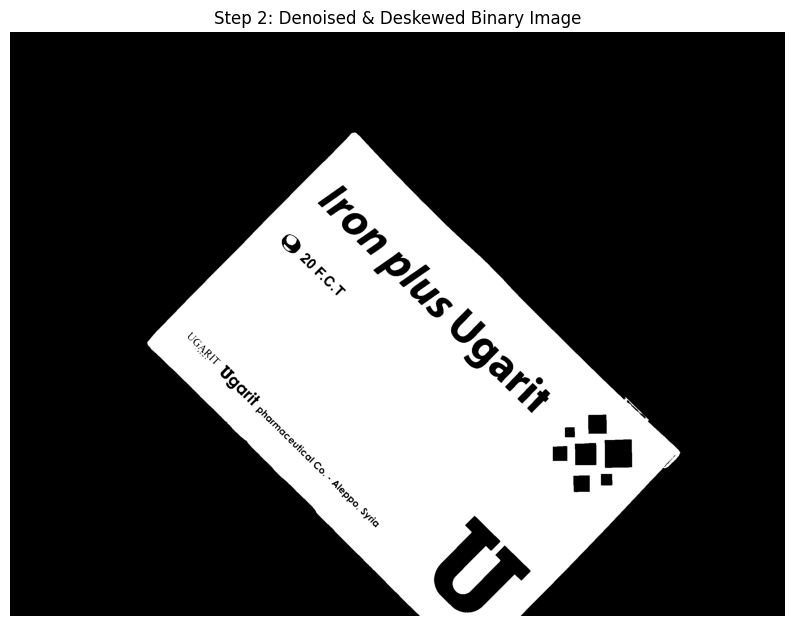

In [4]:
# Step 2: Denoising & Optimal Binarization
# 1. Denoising (Using the rotated_gray from Step 1)
denoised_image = cv2.fastNlMeansDenoising(rotated_gray, None, 10, 7, 21)

# 2. Apply Otsu's Thresholding directly on the denoised grayscale image
ret, thresh_image = cv2.threshold(denoised_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display the result
plt.figure(figsize=(10,10))
plt.imshow(thresh_image, cmap='gray')
plt.title("Step 2: Denoised & Deskewed Binary Image")
plt.axis('off')
plt.show()

#### **Step 4: Integrated OCR Pipeline**
This cell executes the full workflow using the **Bounding Box** method:
1. **Geometric Deskewing:** Attempting rotation based on the minimum area rectangle.
2. **Bilingual Extraction:** Processing Arabic/English text with `PSM 3`.
3. **Automated Evaluation:** Reporting status via the **Traffic Light System** to identify extraction failure.

In [5]:
# 1. Image Scaling (Resizing to 2x)
img_resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# 2. Deskewing Logic
# Bounding Box (Geometric)
gray_for_deskew = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
thresh = cv2.threshold(gray_for_deskew, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
coords = np.column_stack(np.where(thresh > 0))
angle = cv2.minAreaRect(coords)[-1]

if angle < -45:
    angle = -(90 + angle)
else:
    angle = -angle

(h, w) = gray_for_deskew.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, angle, 1.0)
rotated_img = cv2.warpAffine(img_resized, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

# 3. Denoising (On the rotated image)
distorted = cv2.fastNlMeansDenoisingColored(rotated_img, None, 10, 10, 7, 21)

# 4. Binarization
gray = cv2.cvtColor(distorted, cv2.COLOR_BGR2GRAY)
final_processed = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

# Convert to PIL for Tesseract
pil_image = Image.fromarray(final_processed)

# 5. Final OCR Extraction (Bilingual + PSM 3)
custom_config = r'-l ara+eng --psm 3'
raw_text = pytesseract.image_to_string(pil_image, config=custom_config).strip()

# 6. Traffic Light Logic
def generate_traffic_report(text):
    clean_text = "".join(text.split())
    noise_count = sum(1 for char in clean_text if not char.isalnum())
    if len(clean_text) == 0:
        return "🔴 RED: OCR Failed"
    elif noise_count > (len(clean_text) * 0.2):
        return "🟡 YELLOW: Low Accuracy (Check Tilt/Noise)"
    else:
        return "🟢 GREEN: Success"

status_message = generate_traffic_report(raw_text)

# 7. Final Output
print("="*40)
print(f"REPORT STATUS: {status_message}")
print(f"DETECTED ANGLE: {angle:.2f}°")
print("="*40)
print("EXTRACTED CONTENT:")
print(raw_text if raw_text else "[No Text Detected]")
print("="*40)

REPORT STATUS: 🔴 RED: OCR Failed
DETECTED ANGLE: -0.00°
EXTRACTED CONTENT:
[No Text Detected]


---

### **Case 2: Severe Image Skew (Enhanced Hough Transform Method)**
* **Challenge:** The same 45-degree tilted image is used. This test evaluates the effectiveness of the new "Line-Detection" logic.
* **Observation:** We will see how the Hough Transform accurately identifies text baselines, allowing for perfect horizontal alignment and successful bilingual OCR extraction.

#### **Step 1: Image Upload & Visualization**
Uploading the medicine label and displaying the original state to visualize the degree of skew before any processing.

Upload image for CASE 2:


Saving photo_2026-02-25_10-06-30.jpg to photo_2026-02-25_10-06-30 (2).jpg


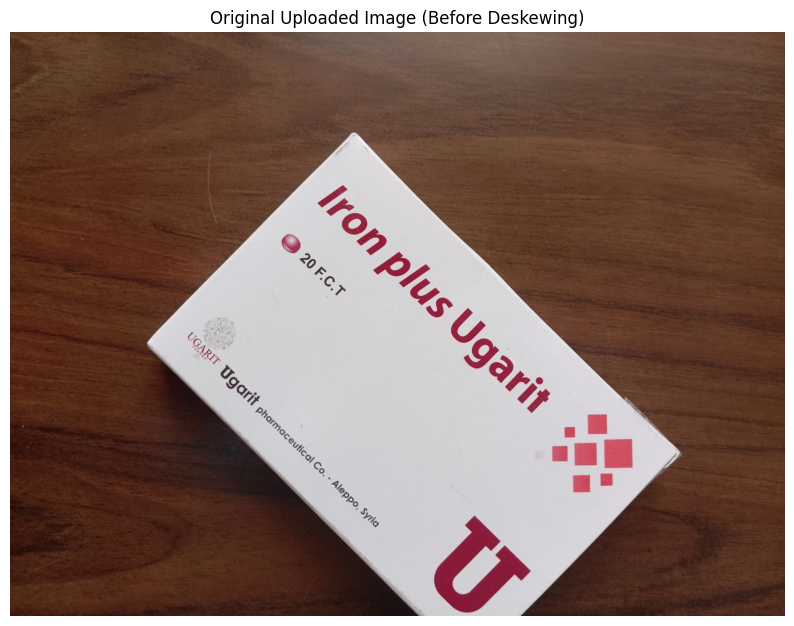

In [6]:
print("Upload image for CASE 2:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
image = cv2.imread(file_name)

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Uploaded Image (Before Deskewing)")
plt.axis('off')
plt.show()

#### **Step 2: Adaptive Scaling & Enhanced Deskewing (Hough Transform)**
Resizing the image and applying the **Progressive Hough Transform** to detect the true median angle of the text lines, ensuring precise rectification.

Detected Angle: 44.08 degrees. Correction applied.


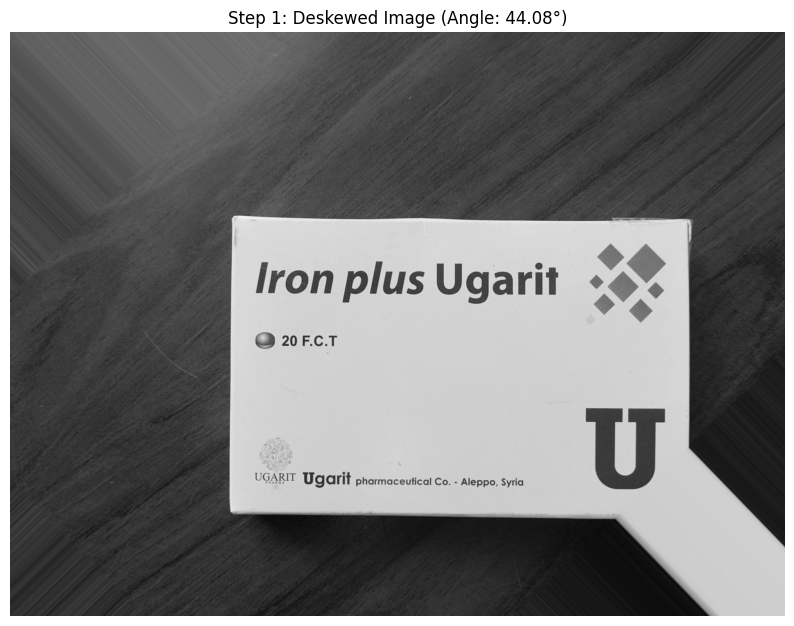

In [7]:
# Step 1: Adaptive Resizing & Deskewing
# 1. Resize first
img_resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# 2. Convert to Grayscale
gray_image = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

# 3. Enhanced Deskewing Logic (Hough Transform)
# Threshold to find text
thresh = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

# Detect lines using Hough Transform to find the real text angle
edges = cv2.Canny(thresh, 50, 150, apertureSize=3)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 100, minLineLength=100, maxLineGap=10)

angles = []
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle_rad = np.arctan2(y2 - y1, x2 - x1)
        angles.append(np.degrees(angle_rad))

# Use Median angle to ignore noise lines
angle = np.median(angles) if len(angles) > 0 else 0

# Adjust angle to keep it within reasonable rotation bounds
if abs(angle) > 45:
    angle = angle - 90 if angle > 0 else angle + 90

# 4. Rotate the image
(h, w) = gray_image.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, angle, 1.0)
rotated_gray = cv2.warpAffine(gray_image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

print(f"Detected Angle: {angle:.2f} degrees. Correction applied.")

# Display
plt.figure(figsize=(10,10))
plt.imshow(rotated_gray, cmap='gray')
plt.title(f"Step 1: Deskewed Image (Angle: {angle:.2f}°)")
plt.axis('off')
plt.show()

#### **Step 3: Grayscale Denoising & Binarization**
Optimizing the image for OCR after the deskewing attempt:
1. **Denoising:** Applying `fastNlMeansDenoising` on the grayscale output to eliminate sensor noise.
2. **Binarization:** Using **Otsu’s Thresholding** to create a clean black-and-white input, ensuring maximum contrast for character recognition.

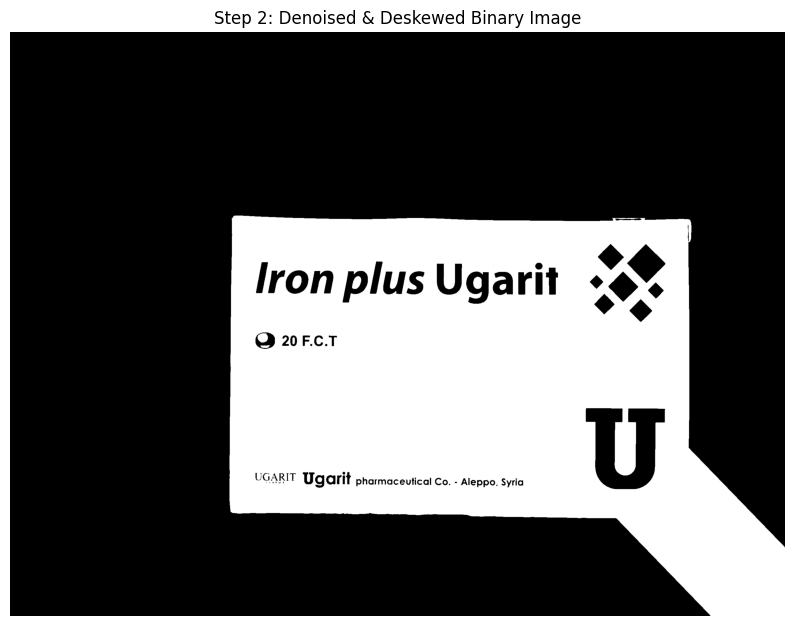

In [8]:
# Step 2: Denoising & Optimal Binarization
# 1. Denoising (Using the rotated_gray from Step 1)
denoised_image = cv2.fastNlMeansDenoising(rotated_gray, None, 10, 7, 21)

# 2. Apply Otsu's Thresholding directly on the denoised grayscale image
ret, thresh_image = cv2.threshold(denoised_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display the result
plt.figure(figsize=(10,10))
plt.imshow(thresh_image, cmap='gray')
plt.title("Step 2: Denoised & Deskewed Binary Image")
plt.axis('off')
plt.show()

#### **Step 4: Integrated OCR Pipeline (Enhanced Logic)**
This cell executes the full workflow using the **Hough Transform** method:
1. **Geometric Rectification:** Detecting text baselines to achieve precise horizontal alignment.
2. **Bilingual Extraction:** Processing Arabic/English text with `PSM 3` on the rectified image.
3. **Automated Evaluation:** Reporting status via the **Traffic Light System** to verify extraction success.

In [9]:
# 1. Image Scaling (Resizing to 2x)
img_resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# 2. Deskewing Logic (Hough Transform - The New Improvement)
gray_for_deskew = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
thresh_for_angle = cv2.threshold(gray_for_deskew, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

# Detect lines to find the true text angle
edges = cv2.Canny(thresh_for_angle, 50, 150, apertureSize=3)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 100, minLineLength=100, maxLineGap=10)

angles = []
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle_rad = np.arctan2(y2 - y1, x2 - x1)
        angles.append(np.degrees(angle_rad))

# Calculate median angle
angle = np.median(angles) if len(angles) > 0 else 0
if abs(angle) > 45:
    angle = angle - 90 if angle > 0 else angle + 90

# Rotate the original resized image
(h, w) = img_resized.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, angle, 1.0)
rotated_img = cv2.warpAffine(img_resized, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

# 3. Denoising (On the rotated image)
distorted = cv2.fastNlMeansDenoisingColored(rotated_img, None, 10, 10, 7, 21)

# 4. Binarization
gray = cv2.cvtColor(distorted, cv2.COLOR_BGR2GRAY)
final_processed = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

# Convert to PIL for Tesseract
pil_image = Image.fromarray(final_processed)

# 5. Final OCR Extraction (Multi-language + PSM 3)
custom_config = r'-l ara+eng --psm 3'
raw_text = pytesseract.image_to_string(pil_image, config=custom_config).strip()

# 6. Traffic Light Logic
def generate_traffic_report(text):
    clean_text = "".join(text.split())
    noise_count = sum(1 for char in clean_text if not char.isalnum())
    if len(clean_text) == 0:
        return "🔴 RED: OCR Failed"
    elif noise_count > (len(clean_text) * 0.2): # 20% threshold for strict accuracy
        return "🟡 YELLOW: Low Accuracy (Check Tilt/Noise)"
    else:
        return "🟢 GREEN: Success"

status_message = generate_traffic_report(raw_text)

# 7. Output the Result
print("="*40)
print(f"REPORT STATUS: {status_message}")
print(f"DETECTED ANGLE: {angle:.2f}°")
print("="*40)
print("EXTRACTED CONTENT:")
print(raw_text if raw_text else "[No Text Detected]")
print("="*40)

REPORT STATUS: 🟢 GREEN: Success
DETECTED ANGLE: 44.08°
EXTRACTED CONTENT:
—

|

lron plus Ugarit ~ 4

oe

© 20F.C.T

UGARIT Ugarit pharmaceutical Co. - Aleppo, Syria U
